# Bayesian AB (For Continuous Updating)
- close-form BETA, continuously update with real data daily
- DO NOT NEED to rerun full MCMC daily for monitoring

As new data comes in, update belief about conversion rates and decide when to stop
- Baysian updating
- Conversion Rate = Beta-Binomial = Closed-form posterior
- instant updates
- no convergence issues
- same math as MCMC

Production workflow notebook
- daily cumulative data
- updates posterior
- tracks P(B>A) and expected loss
- stops early if confident
- sets max days for pilot duration

Key
- not resetting model daily
- updating cumulative counts which updates the posterior


Closed-form solution
- we can compute the answer directly using a formula - no simulation, no MCMC
- we are modeling a conversion rate, data = success out of trials
- this a binomial likelihood, the beta distribution is conjugate to the binomial

Distribution/Key relationship
- we assume Prior: p∼Beta(α,β)
- data: k bookings out of n applications
- the posterior is: p∣ data∼Beta(α+k, β+(n−k))

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ====== UPDATE THIS DAILY ======

data = [
    # day, apps_A, bookings_A, apps_B, bookings_B
    [1, 150, 30, 150, 20],
    [2, 300, 65, 300, 42],
    [3, 450, 92, 450, 65],
]

df = pd.DataFrame(data, columns=[
    "day", "apps_A", "bookings_A", "apps_B", "bookings_B"
])

max_days = 14
prob_threshold = 0.95
loss_threshold = 0.001

In [3]:
history = []
decision_day = None

for _, r in df.iterrows():

    alpha_A = 1 + r["bookings_A"]
    beta_A  = 1 + (r["apps_A"] - r["bookings_A"])

    alpha_B = 1 + r["bookings_B"]
    beta_B  = 1 + (r["apps_B"] - r["bookings_B"])

    samples = 50000

    p_A = np.random.beta(alpha_A, beta_A, samples)
    p_B = np.random.beta(alpha_B, beta_B, samples)

    prob_B_better = np.mean(p_B > p_A)

    loss_if_A = np.mean(np.maximum(p_B - p_A, 0))
    loss_if_B = np.mean(np.maximum(p_A - p_B, 0))

    expected_loss = min(loss_if_A, loss_if_B)

    history.append({
        "day": r["day"],
        "prob_B_better": prob_B_better,
        "expected_loss": expected_loss
    })

    if (prob_B_better > prob_threshold and
        expected_loss < loss_threshold and
        decision_day is None):

        decision_day = r["day"]

history_df = pd.DataFrame(history)

In [4]:
latest_day = df["day"].max()

if decision_day:
    print(f"✅ Stop early on Day {decision_day}")
elif latest_day >= max_days:
    print("⏰ Reached max duration → make final decision")
else:
    print("⏳ Continue experiment")

⏳ Continue experiment


In [5]:
print(history_df.tail(1))

   day  prob_B_better  expected_loss
2    3         0.0091       0.000079


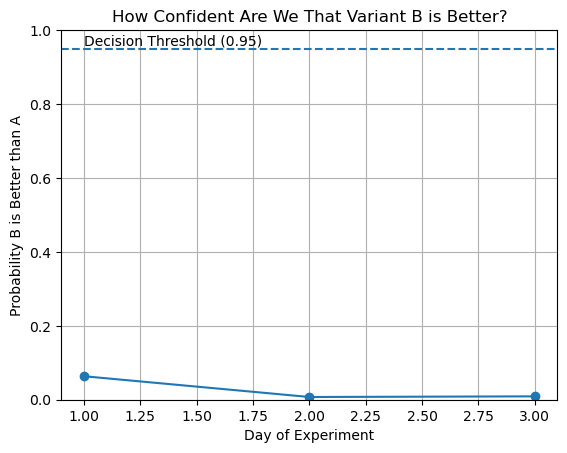

In [ ]:
# probability that B beats A
plt.figure()

plt.plot(history_df["day"], history_df["prob_B_better"], marker='o')

plt.axhline(prob_threshold, linestyle='--')
plt.text(1, prob_threshold + 0.01, f"Decision Threshold ({prob_threshold})")

if decision_day:
    plt.axvline(decision_day, linestyle='--')
    plt.text(decision_day, 0.1, f"Decision Day = {decision_day}", rotation=90)

plt.xlabel("Day of Experiment")
plt.ylabel("Probability B is Better than A")
plt.title("How Confident Are We That Variant B is Better?")

plt.ylim(0, 1)

plt.grid()
plt.show()

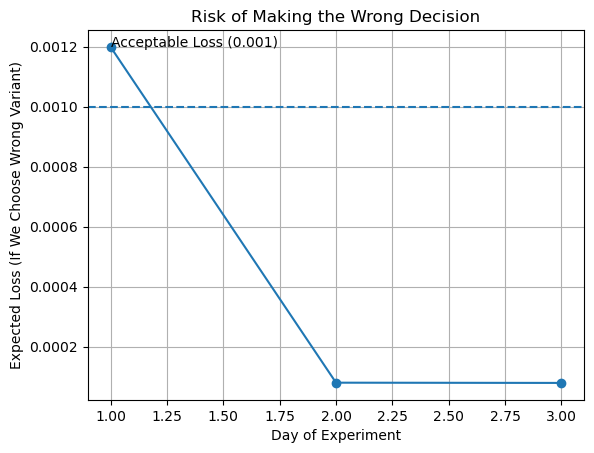

In [9]:
plt.figure()

plt.plot(history_df["day"], history_df["expected_loss"], marker='o')

plt.axhline(loss_threshold, linestyle='--')
plt.text(1, loss_threshold + 0.0002, f"Acceptable Loss ({loss_threshold})")

if decision_day:
    plt.axvline(decision_day, linestyle='--')
    plt.text(decision_day, loss_threshold * 2, f"Decision Day = {decision_day}", rotation=90)

plt.xlabel("Day of Experiment")
plt.ylabel("Expected Loss (If We Choose Wrong Variant)")
plt.title("Risk of Making the Wrong Decision")

plt.grid()
plt.show()